In [1]:
import albumentations as A
print(f"Albumentations version: {A.__version__}")

Albumentations version: 2.0.6


In [30]:
from PIL import Image
import os
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2
from dataset_class import GlacierSegDataset
import segmentation_models_pytorch as smp
import tqdm
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import gc
import psutil
import numpy as np
# wandb.login()


# Check memory status
def print_memory_stats():
    process = psutil.Process(os.getpid())
    print(f"Process memory usage: {process.memory_info().rss / (1024 * 1024):.2f} MB")
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            print(f"GPU {i} memory allocated: {torch.cuda.memory_allocated(i) / (1024 * 1024):.2f} MB")
            print(f"GPU {i} memory cached: {torch.cuda.memory_cached(i) / (1024 * 1024):.2f} MB")

#Check memory before and after training
print_memory_stats()


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    epoch_loss = 0
    print("Starting training for one epoch...")
    print("Memory before training:")
    print_memory_stats()

    pbar = tqdm.tqdm(enumerate(loader), total=len(loader))
    for i, (images, masks) in pbar:
        
        images = images.to(device)  # Shape: [batch_size, 1, height, width]
        masks = masks.to(device).squeeze(1)  # Shape: [batch_size, height, width]
        print(f"images: {images.shape} masks: {masks.shape}")
        
        optimizer.zero_grad()
        outputs = model(images)
        print(f"outputs: {outputs.shape}")
        #print(f"for batch {i}, input shape: {images.shape} outputs shape: {outputs.shape}, masks shape: {masks.shape}")
        loss = 0
        for i in range(images.shape[0]):
            loss += criterion(outputs[i].squeeze(0), masks[i].squeeze(0))
        #loss = criterion(outputs, masks)
        print(f"loss: {loss.item()}")
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()

        # Log batch-level metrics (less frequently to avoid too many logs)
        
        pbar.set_postfix(loss=loss.item())      

    print("Finished training for one epoch.")

    print("Memory after training:")
    print_memory_stats()
    # Clear cache and collect garbage
    torch.cuda.empty_cache()
    gc.collect()
    

    return epoch_loss / len(loader)


Process memory usage: 2352.56 MB


In [31]:
from segmentation_models_pytorch.losses.dice import DiceLoss
from einops import rearrange
import torch.nn as nn
from scipy.ndimage.morphology import distance_transform_edt as edt

class DistanceMapBCE(nn.Module):
    def __init__(self, device, w, k, relax):
        super(DistanceMapBCE, self).__init__()
        self.device = device
        self.w = w  # paramter w of dmap loss
        self.k = k  # parameter k of dmap loss
        self.relax = relax

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        distance_maps = torch.stack(list(map(self.distance_map, torch.unbind(targets))))
        preds = torch.stack(list(map(torch.mul, torch.unbind(preds), torch.unbind(distance_maps))))
        criterion = DiceLoss('binary', from_logits=False)
        targets = rearrange(targets, 'b h w -> b 1 h w')
        loss = criterion(preds, targets)
        return loss

    def distance_map(self, target):
        if target.max() == 0:
            distance_map_image = 1 - target
        else:
            kernel = np.ones((self.w, self.w), dtype=np.float32)
            fat_gt = cv2.dilate(target.cpu().numpy(), kernel)
            euclidean_distance_transformed = torch.from_numpy(edt(fat_gt)).to(self.device).type(torch.float32)  # normalize to 0 - 1 for edt change background to 0 only edt inside the dilated front
            soft_gt = torch.sigmoid(torch.div(euclidean_distance_transformed, self.relax))
            # Normalize this so it is between 0 and 1 (-> all background will be 0)
            soft_gt = torch.sub(soft_gt, torch.min(soft_gt))
            soft_gt = torch.div(soft_gt, torch.max(soft_gt))
            distance_map_image = soft_gt + (1 - torch.from_numpy(fat_gt).to(self.device).type(torch.float32)) * self.k

        return distance_map_image


/tmp/ipykernel_2092068/925840931.py:4: DeprecationWarning: Please import `distance_transform_edt` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import distance_transform_edt as edt


In [32]:

def main():


  
    #all the images are different sizes -BUT 
    #this was accounted for in data_preprocessing!!

    #now the correct images are stored in these 3 paths

    train_data_path = '/gws/nopw/j04/iecdt/amorgan/data_copy/sar_images/train'
    val_data_path = '/gws/nopw/j04/iecdt/amorgan/data_copy/sar_images/val'
    test_data_path = '/gws/nopw/j04/iecdt/amorgan/data_copy/sar_images/test'

    parent_dir = "/gws/nopw/j04/iecdt/amorgan/data_copy"
    #original_images_file = "/home/users/amorgan/Calving_Fronts_and_Where_to_Find_Them/original_square_images_actual_names.txt"

    # dataset = GlacierSegDataset(mode='train', parent_dir = parent_dir)
    # image, mask, front = dataset[0]  # Get first sample


    train_dataset_mask = GlacierSegDataset(mode='train', parent_dir=parent_dir, label_type="mask")
    # val_dataset_mask = GlacierSegDataset(mode='val', parent_dir=parent_dir, label_type="mask")
    # test_dataset_mask = GlacierSegDataset(mode='test', parent_dir=parent_dir, label_type="mask")

    # Use 'front' as labels
    # train_dataset_front = GlacierSegDataset(mode='train', parent_dir=parent_dir, label_type="front")
    # val_dataset_front = GlacierSegDataset(mode='val', parent_dir=parent_dir, label_type="front")
    # test_dataset_front = GlacierSegDataset(mode='test', parent_dir=parent_dir, label_type="front")

    # image, label = train_dataset_mask[0]  # Get first sample

    # print(f"Image shape: {image.shape}") 
    # print(f"Label shape: {label.shape}") # label can be either mask or front depending on the label_type

    try:
        image, label = train_dataset_mask[0]  # Get first sample
        print(f"Image shape: {image.shape}")
        print(f"Label shape: {label.shape}")
    except Exception as e:
        print(f"Error accessing first sample: {e}")
        return


    model = smp.Unet(  
        encoder_name="resnet34",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
        encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=4,                      # model output channels (number of classes in your dataset), # class ids area=0, stone=1, glacier=2, ocean with ice melange=3
    )
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Loss and optimizer
    criterion = DistanceMapBCE(device, w=1, k=1, relax=1)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    print(f"Using device: {device}")
    model.to(device)

    train_loader = DataLoader(train_dataset_mask, batch_size=2, shuffle=True)
    # val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)


    print("Starting training loop...")

    epoch_losses = []  # To store loss values for visualization
    for epoch in range(10):
        print(f"Epoch {epoch + 1} starting...")
    
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        epoch_losses.append(train_loss)  # Save loss for visualization
    
        print(f"Epoch {epoch+1}, Loss: {train_loss:.4f}")
    print("Training loop completed.")

    # Save the model
    torch.save(model.state_dict(), "testy_amy_trained_model_256.pth")
    

if __name__ == "__main__":
    print("about to go!")
    main()

about to go!
Initializing GlacierSegDataset in train mode...
Number of images: 46740, masks: 46740, fronts: 46740
Image shape: torch.Size([1, 256, 256])
Label shape: torch.Size([1, 4, 256, 256])


/usr/lib64/python3.9/tarfile.py:2268: RuntimeWarning: The default behavior of tarfile extraction has been changed to disallow common exploits (including CVE-2007-4559). By default, absolute/parent paths are disallowed and some mode bits are cleared. See https://access.redhat.com/articles/7004769 for more details.
  warnings.warn(


Using device: cpu
Starting training loop...
Epoch 1 starting...
Starting training for one epoch...
Memory before training:
Process memory usage: 2364.37 MB


  0%|          | 0/23370 [00:00<?, ?it/s]

images: torch.Size([2, 1, 256, 256]) masks: torch.Size([2, 4, 256, 256])
outputs: torch.Size([2, 4, 256, 256])
loss: 1.325181484222412


...

images: torch.Size([2, 1, 256, 256]) masks: torch.Size([2, 4, 256, 256])
outputs: torch.Size([2, 4, 256, 256])
loss: 1.2353475093841553


  0%|          | 5/23370 [01:14<98:49:12, 15.23s/it, loss=1.24]

images: torch.Size([2, 1, 256, 256]) masks: torch.Size([2, 4, 256, 256])
outputs: torch.Size([2, 4, 256, 256])
loss: 1.3254026174545288


  0%|          | 5/23370 [01:26<111:53:48, 17.24s/it, loss=1.24]


KeyboardInterrupt: 

In [2]:
train_data_path = '/gws/nopw/j04/iecdt/amorgan/data_copy/sar_images/train'
val_data_path = '/gws/nopw/j04/iecdt/amorgan/data_copy/sar_images/val'
test_data_path = '/gws/nopw/j04/iecdt/amorgan/data_copy/sar_images/test'

parent_dir = "/gws/nopw/j04/iecdt/amorgan/data_copy"
#original_images_file = "/home/users/amorgan/Calving_Fronts_and_Where_to_Find_Them/original_square_images_actual_names.txt"

# dataset = GlacierSegDataset(mode='train', parent_dir = parent_dir)
# image, mask, front = dataset[0]  # Get first sample


train_dataset_mask = GlacierSegDataset(mode='train', parent_dir=parent_dir, label_type="mask")

Initializing GlacierSegDataset in train mode...
Number of images: 46740, masks: 46740, fronts: 46740


Image shape: torch.Size([1, 256, 256])
Label shape: torch.Size([1, 4, 256, 256])


Text(0.5, 1.0, 'Image')

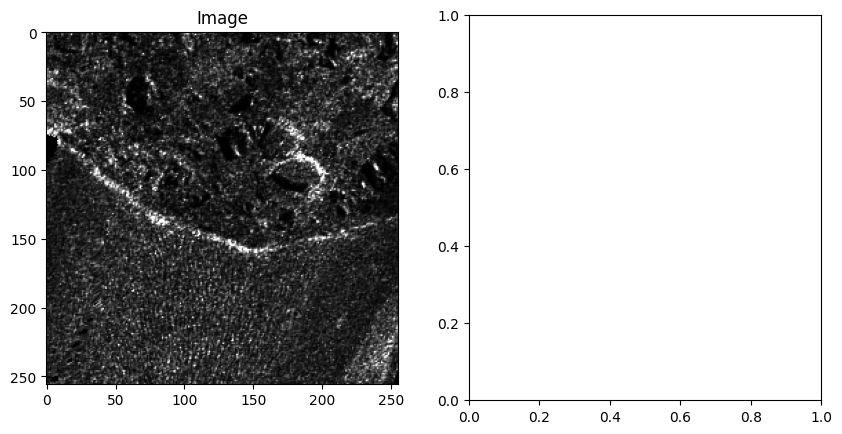

In [3]:
image, label = train_dataset_mask[1]  # Get first sample
print(f"Image shape: {image.shape}")
print(f"Label shape: {label.shape}")
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image.squeeze(0), cmap='gray')
axs[0].set_title("Image")


In [4]:
model = smp.Unet(  
        encoder_name="resnet34",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
        encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=4,                      # model output channels (number of classes in your dataset), # class ids area=0, stone=1, glacier=2, ocean with ice melange=3
    )

/usr/lib64/python3.9/tarfile.py:2268: RuntimeWarning: The default behavior of tarfile extraction has been changed to disallow common exploits (including CVE-2007-4559). By default, absolute/parent paths are disallowed and some mode bits are cleared. See https://access.redhat.com/articles/7004769 for more details.
  warnings.warn(


In [5]:
model

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [8]:
image.shape

torch.Size([1, 256, 256])

In [12]:
mask_uns = label.unsqueeze(0)

In [14]:
pred = model(image.unsqueeze(0))

In [15]:
pred.shape, mask_uns.shape

(torch.Size([1, 4, 256, 256]), torch.Size([1, 1, 4, 256, 256]))

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = DistanceMapBCE(device, w=1, k=1, relax=1)
#loss = criterion(y_hat, y)

In [21]:
hda = pred.squeeze(0)
sda = mask_uns.squeeze(0).squeeze(0)

In [22]:
criterion(hda, sda)

tensor(0.6626, grad_fn=<MeanBackward0>)

In [ ]:
class IoULoss(nn.Module):
    """
    A class for the Jaccard index loss function.
    """
    def __init__(self, smooth=1e-6):
        """
        Initializes the Jaccard index loss function.

        Args:
            smooth (float): A small constant to avoid division by zero.
        """
        super(IoULoss, self).__init__()
        self.smooth = smooth

    def forward(self, y_pred, y_true):
        """
        Computes the Jaccard index loss.

        Args:
            y_pred (torch.Tensor): The predicted output.
            y_true (torch.Tensor): The ground truth labels.

        Returns:
            torch.Tensor: The computed Jaccard index loss.
        """
        intersection = torch.sum(y_pred * y_true)
        union = torch.sum(y_pred) + torch.sum(y_true) - intersection
        return 1 - (intersection + self.smooth) / (union + self.smooth)

In [37]:
pred.shape, mask_uns.squeeze(0).shape

(torch.Size([1, 4, 256, 256]), torch.Size([1, 4, 256, 256]))

In [ ]:
crit = IoULoss()
crit(pred, mask_uns.squeeze(0))

tensor(1.6527, grad_fn=<RsubBackward1>)

In [ ]:
from torchmetrics import JaccardIndex    
jaccard = JaccardIndex(num_classes=4, task="multiclass", threshold=0.5)


RuntimeError: bincount only supports 1-d non-negative integral inputs.